## References

1. **Tian, J., Yang, H., Cai, J., Yang, Y., Li, X., Yi, Z., & Wang, L. (2025).** 
**Progress in clustering algorithms for astronomical spectra over a decade. Astronomical Techniques and Instrument, 2(0), 1–16.**  
     
   https://doi.org/10.61977/ati2025030

2. **Kuhn, M. A., & Feigelson, E. D. (2017). Mixture models in astronomy. arXiv.**  
   
   https://arxiv.org/abs/1711.11101



# Gaussian Mixture Model (GMM) Workflow for Astronomical Object Clustering

This notebook is a **GMM workflow** for clustering astronomical objects.

- it uses **same feature set** as K Means and GMM methods 
- it keeps the **same evaluation family** used in the earlier notebook
- it uses the **scaled data already prepared by the team**
- This notebook aims to explain:
  1. why GMM is appropriate,
  2. how to choose the number of components \(K\),
  3. how to choose the covariance structure,
  4. how to justify the remaining hyperparameters,
  5. how to evaluate the fitted model(s).


Per project decision, the model is trained on:

- `u-g`
- `g-r`
- `r-i`
- `i-z`
- `redshift_log`


## 1. Pipeline overview

The end-to-end pipeline in this notebook is:

1. **Load the team's scaled dataset** from `../astral_data.csv`.
2. **Justify GMM** as a probabilistic alternative to K-Means when class boundaries are blurred and cluster covariance matters.
3. **Select the number of components \(K\)** using **BIC** as the primary criterion and **AIC** as a supporting criterion.
4. **Always attempt \(K=3\)** because it is the domain-grounded candidate, then decide whether a second branch is needed if a different \(K\) is materially better.
5. **Compare covariance structures** and verify whether `full` is preferred.
6. **Fix the remaining hyperparameters** (`n_init`, `reg_covar`, `max_iter`, `init_params`, `random_state`)
7. **Fit the final GMM model(s)**.
8. **Evaluate them** using the same family of metrics as the other models  :
   silhouette, Davies–Bouldin, Calinski–Harabasz, ARI, NMI, purity, cluster composition, PCA visualisation, and membership-probability analysis.
9. **Interpret the results** in terms of overlap between stars, galaxies, and quasars.


In [23]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)
from sklearn.decomposition import PCA

## 2. Load feature matrix

In [ ]:
# -------------------------------------------------------------------
# Configuration
# -------------------------------------------------------------------
SCALED_FEATURE_PATH = Path("../Dataset/astral_data.csv")
RAW_LABEL_PATH = Path("../Dataset/star-galaxy-quasar.csv")

FEATURE_COLS = ['u-g', 'g-r', 'r-i', 'i-z', 'redshift_log']
TARGET_COL = "class"

# -------------------------------------------------------------------
# Load the team's scaled feature table
# -------------------------------------------------------------------
scaled_df = pd.read_csv(SCALED_FEATURE_PATH)

missing_features = [c for c in FEATURE_COLS if c not in scaled_df.columns]
if missing_features:
    raise ValueError(
        f"Missing expected feature columns in {SCALED_FEATURE_PATH}: {missing_features}"
    )

X = scaled_df[FEATURE_COLS].copy()

if TARGET_COL in scaled_df.columns:
    y = scaled_df[TARGET_COL].copy()
else:
    raw_labels = pd.read_csv(RAW_LABEL_PATH, skiprows=1)
    if TARGET_COL not in raw_labels.columns:
        raise ValueError(f"Could not find '{TARGET_COL}' in {RAW_LABEL_PATH}")
    if len(raw_labels) != len(scaled_df):
        raise ValueError(
            "Scaled feature table and raw label table have different row counts. "
            "Please verify row alignment before proceeding."
        )
    y = raw_labels[TARGET_COL].copy()

print("Feature matrix shape:", X.shape)
print("Feature columns:", FEATURE_COLS)
print("\nClass distribution:")
print(y.value_counts(dropna=False))
X.head()

Feature matrix shape: (9733, 5)
Feature columns: ['u-g', 'g-r', 'r-i', 'i-z', 'redshift_log']

Class distribution:
class
GALAXY    8423
QSO        685
STAR       625
Name: count, dtype: int64


,u-g,g-r,r-i,i-z,redshift_log
0,0.282719,0.199441,0.311683,0.203881,-0.145579
1,0.082746,0.183756,1.123312,0.428709,-0.549480
2,-0.312019,-0.067587,-0.128764,0.126954,-0.235675
3,0.397933,0.144873,0.426494,0.523488,-0.196892
4,-0.264895,-0.435012,-0.160010,-0.758546,-0.328149


## 3. Why try a Gaussian Mixture Model?

GMM have provided strong support for galaxy research, in particular demonstrating advantages in handling high-redshift unlabeled datasets (Tian et al., 2025).


The K-Means section already established an important limitation: centroid-based clustering can recover the strongest large-scale structure, but it may struggle when **class boundaries are not sharp**.


In this dataset, stars, galaxies, and QSOs are not expected to form perfectly separated spherical clouds in feature space because colour indices can overlap


K-Means assigns each point to the nearest centroid and implicitly favors spherical clusters.  
GMM instead models the data as a weighted mixture of multivariate Gaussian components, giving it 2 unique properties:
1. **Soft assignments**: each object gets a membership probability instead of a forced hard label.
2. **Flexible cluster geometry**: clusters can be elliptical rather than spherical.



## 4. Choosing the number of components \(K\)

This notebook uses **BIC** as the main model-selection criterion and **AIC** as a supporting criterion.

This is because shifting to maximum likelihood estimation of parametric mixture models can lead to more stable and reproducible classifications. 
In particular, the number of components emerges from quantitative model selection measures such as the BIC rather than from subjective decisions (Kuhn & Feigelson, 2017).

### Properties of BIC and AIC

Both criteria reward better fit through the likelihood term, but penalize added complexity from increasing number of components.


### How we will decide here

1. Fit GMMs across a grid of \(K\) values (2-10) using **`covariance_type='full'`** as the initial, most flexible baseline.
2. Plot and tabulate BIC and AIC.
3. Inspect the **marginal gains** from increasing \(K\).
4. Always keep **\(K=3\)** in view because it is the domain-grounded candidate.
5. If \(K=3\) is not the BIC optimum, build **two branches**:
   - one model with \(K=3\),
   - one model with the better-supported \(K\).

It allow us to compare the performance between BIC optimum and the ground truth.

In [26]:
def fit_k_scan(
    X: pd.DataFrame,
    k_values=range(1, 11),
    covariance_type: str = "full",
    n_init: int = 20,
    reg_covar: float = 1e-6,
    max_iter: int = 500,
    random_state: int = 42,
):
    """Fit a sequence of GMMs for model-order selection."""
    rows = []
    models = {}

    for k in k_values:
        model = GaussianMixture(
            n_components=k,
            covariance_type=covariance_type,
            n_init=n_init,
            reg_covar=reg_covar,
            max_iter=max_iter,
            init_params="kmeans",
            random_state=random_state,
        )
        model.fit(X)

        bic = model.bic(X)
        aic = model.aic(X)

        rows.append({
            "k": k,
            "bic": bic,
            "aic": aic,
            "avg_log_likelihood": model.score(X),
            "n_parameters": model._n_parameters(),
        })
        models[k] = model

    out = pd.DataFrame(rows).sort_values("k").reset_index(drop=True)

    out["bic_improvement_vs_prev"] = out["bic"].shift(1) - out["bic"]
    out["aic_improvement_vs_prev"] = out["aic"].shift(1) - out["aic"]
    out["delta_bic_from_best"] = out["bic"] - out["bic"].min()
    out["delta_aic_from_best"] = out["aic"] - out["aic"].min()

    return out, models


k_scan_results, k_scan_models = fit_k_scan(X)

display(k_scan_results.style.format({
    "bic": "{:,.2f}",
    "aic": "{:,.2f}",
    "avg_log_likelihood": "{:.6f}",
    "bic_improvement_vs_prev": "{:,.2f}",
    "aic_improvement_vs_prev": "{:,.2f}",
    "delta_bic_from_best": "{:,.2f}",
    "delta_aic_from_best": "{:,.2f}",
}))

,k,bic,aic,avg_log_likelihood,n_parameters,bic_improvement_vs_prev,aic_improvement_vs_prev,delta_bic_from_best,delta_aic_from_best
0,1,"130,310.36","130,166.69",-6.684819,20,nan,nan,"73,025.37","74,383.00"
1,2,"89,083.95","88,789.43",-4.557045,41,"41,226.41","41,377.26","31,798.95","33,005.74"
2,3,"81,054.20","80,608.83",-4.134636,62,"8,029.75","8,180.60","23,769.20","24,825.14"
3,4,"73,177.01","72,580.80",-3.720066,83,"7,877.19","8,028.04","15,892.01","16,797.11"
4,5,"69,332.21","68,585.15",-3.512645,104,"3,844.80","3,995.65","12,047.21","12,801.46"
5,6,"64,719.40","63,821.49",-3.265770,125,"4,612.81","4,763.66","7,434.40","8,037.80"
6,7,"62,215.23","61,166.47",-3.127220,146,"2,504.16","2,655.01","4,930.24","5,382.78"
7,8,"59,992.72","58,793.11",-3.003139,167,"2,222.52","2,373.36","2,707.72","3,009.42"
8,9,"58,883.52","57,533.06",-2.936251,188,"1,109.20","1,260.05","1,598.52","1,749.37"
9,10,"57,285.00","55,783.69",-2.844225,209,"1,598.52","1,749.37",0.00,0.00


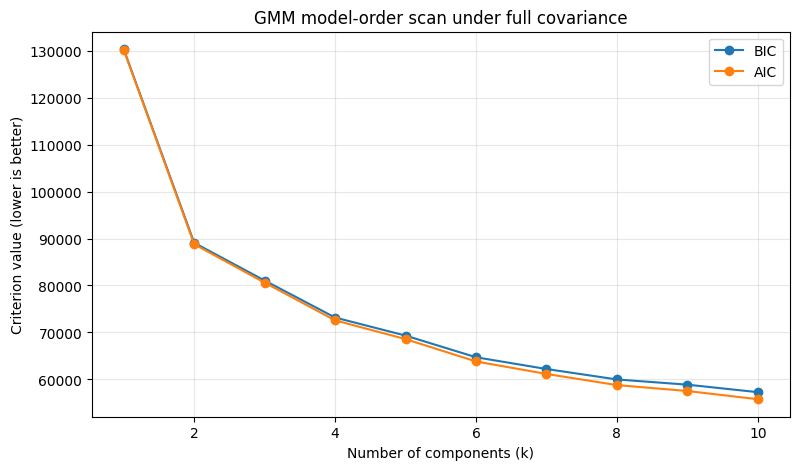

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_scan_results["k"], k_scan_results["bic"], marker="o", label="BIC")
ax.plot(k_scan_results["k"], k_scan_results["aic"], marker="o", label="AIC")
ax.set_title("GMM model-order scan under full covariance")
ax.set_xlabel("Number of components (k)")
ax.set_ylabel("Criterion value (lower is better)")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

### Interpreting the \(K\)-selection plot

From the plot, the decision logic is:

- **BIC prefers \(K =10\)**, then we still keep \(K=3\) as a comparison branch and fit a second model at the BIC-preferred \(K = 10\).


In [28]:
bic_best_k = int(k_scan_results.loc[k_scan_results["bic"].idxmin(), "k"])
aic_best_k = int(k_scan_results.loc[k_scan_results["aic"].idxmin(), "k"])

print(f"BIC-optimal k: {bic_best_k}")
print(f"AIC-optimal k: {aic_best_k}")

if bic_best_k == 3:
    candidate_ks = [3]
    print("\nDecision: retain a single branch with k = 3 (BIC primary).")
else:
    candidate_ks = sorted({3, bic_best_k})
    print(f"\nDecision: build two branches for comparison: k = {candidate_ks}")

BIC-optimal k: 10
AIC-optimal k: 10

Decision: build two branches for comparison: k = [3, 10]


## 5. Choosing the covariance structure

Once the candidate \(K\) values are fixed, the next step is to decide how flexible each component covariance matrix should be.

The four common options are:

- `spherical`: one variance per component,
- `diag`: one variance per feature per component, but no covariance terms,
- `tied`: a single covariance matrix shared across all components,
- `full`: each component has its own full covariance matrix.


### Decision principle used

We compare covariance families empirically for each candidate \(K\), again using:

- **BIC as the primary criterion**
- **AIC as a supporting criterion**


In [29]:
def compare_covariances(
    X: pd.DataFrame,
    k_values,
    covariance_types=("full", "tied", "diag", "spherical"),
    n_init: int = 20,
    reg_covar: float = 1e-6,
    max_iter: int = 500,
    random_state: int = 42,
):
    """Compare covariance structures for each candidate k."""
    rows = []
    models = {}

    for k in k_values:
        for cov in covariance_types:
            model = GaussianMixture(
                n_components=k,
                covariance_type=cov,
                n_init=n_init,
                reg_covar=reg_covar,
                max_iter=max_iter,
                init_params="kmeans",
                random_state=random_state,
            )
            model.fit(X)

            rows.append({
                "k": k,
                "covariance_type": cov,
                "bic": model.bic(X),
                "aic": model.aic(X),
                "avg_log_likelihood": model.score(X),
                "n_parameters": model._n_parameters(),
            })
            models[(k, cov)] = model

    out = pd.DataFrame(rows).sort_values(["k", "bic", "aic"]).reset_index(drop=True)
    return out, models


cov_results, cov_models = compare_covariances(X, candidate_ks)

display(cov_results.style.format({
    "bic": "{:,.2f}",
    "aic": "{:,.2f}",
    "avg_log_likelihood": "{:.6f}",
}))

,k,covariance_type,bic,aic,avg_log_likelihood,n_parameters
0,3,full,"81,054.20","80,608.83",-4.134636,62
1,3,diag,"109,081.96","108,852.10",-5.588621,32
2,3,tied,"114,621.58","114,391.71",-5.873200,32
3,3,spherical,"117,079.71","116,936.05",-6.005139,20
4,10,full,"57,285.00","55,783.69",-2.844225,209
5,10,diag,"73,324.50","72,541.53",-3.715377,109
6,10,spherical,"86,622.48","86,126.83",-4.417386,69
7,10,tied,"99,796.50","99,264.94",-5.091798,74


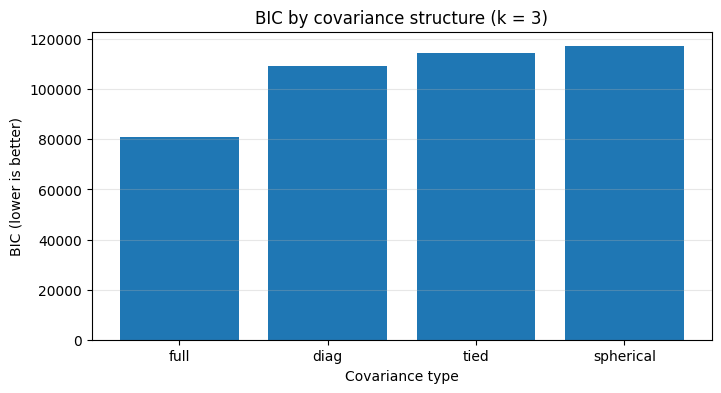

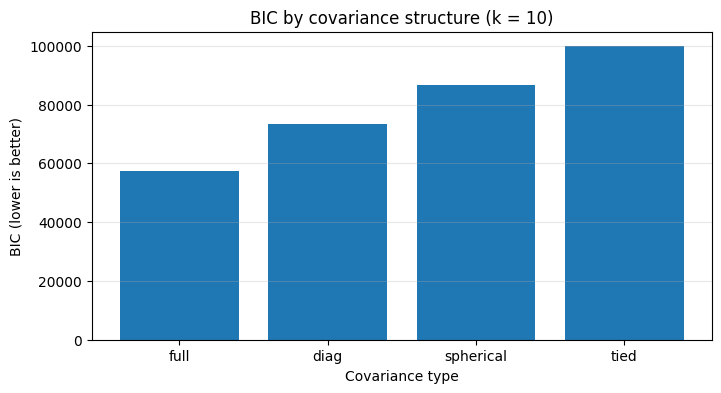

In [30]:
for k in candidate_ks:
    subset = cov_results[cov_results["k"] == k].sort_values("bic")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(subset["covariance_type"], subset["bic"])
    ax.set_title(f"BIC by covariance structure (k = {k})")
    ax.set_xlabel("Covariance type")
    ax.set_ylabel("BIC (lower is better)")
    ax.grid(axis="y", alpha=0.3)
    plt.show()

In [31]:
best_cov_by_k = (
    cov_results.sort_values(["k", "bic", "aic"])
    .groupby("k", as_index=False)
    .first()[["k", "covariance_type", "bic", "aic"]]
)

print("Best covariance type by candidate k:")
display(best_cov_by_k)

Best covariance type by candidate k:


,k,covariance_type,bic,aic
0,3,full,81054.195948,80608.832746
1,10,full,57284.995013,55783.690025


## 6. Other hyperparameters

The remaining hyperparameters are chosen to make the fitting process more stable rather than to materially change the model class.

### `n_init = 20`
Expectation–Maximization can converge to local optima. Using multiple initializations reduces the chance that a poor local solution is mistaken for the final answer.

### `init_params = 'kmeans'`
This gives EM a more stable starting partition than a purely random initialization.

### `reg_covar = 1e-6`
This adds a very small ridge term to each covariance matrix. It is mainly a numerical safeguard against nearly singular covariance estimates.

### `max_iter = 500`
This is a conservative upper bound so the optimization is unlikely to stop prematurely.

### `random_state = 42`
This is included purely for reproducibility.

These settings are deliberately practical rather than exotic: the main substantive choices in this notebook are still **\(K\)** and **covariance structure**.

In [32]:
FINAL_N_INIT = 20
FINAL_REG_COVAR = 1e-6
FINAL_MAX_ITER = 500
FINAL_INIT_PARAMS = "kmeans"
FINAL_RANDOM_STATE = 42

## 7. Fit the final models

For each candidate \(K\):

1. fit the final model,
2. evaluate it with the same metric family used in the earlier notebook.



In [33]:
def purity_score(y_true, y_pred):
    contingency = pd.crosstab(
        pd.Series(y_true, name="true"),
        pd.Series(y_pred, name="cluster")
    )
    return contingency.max(axis=0).sum() / contingency.values.sum()


def cluster_label_mapping(y_true, cluster_labels):
    contingency = pd.crosstab(
        pd.Series(y_true, name="true"),
        pd.Series(cluster_labels, name="cluster")
    )
    mapping = contingency.idxmax(axis=0).to_dict()
    mapped_labels = pd.Series(cluster_labels).map(mapping)
    return mapping, mapped_labels, contingency


def normalized_entropy(proba):
    proba = np.clip(proba, 1e-12, 1.0)
    ent = -(proba * np.log(proba)).sum(axis=1)
    return ent / np.log(proba.shape[1])


def evaluate_gmm(model, X: pd.DataFrame, y: pd.Series):
    cluster_labels = model.predict(X)
    proba = model.predict_proba(X)

    metrics = {
        "k": model.n_components,
        "covariance_type": model.covariance_type,
        "bic": model.bic(X),
        "aic": model.aic(X),
        "avg_log_likelihood": model.score(X),
        "ari": adjusted_rand_score(y, cluster_labels),
        "nmi": normalized_mutual_info_score(y, cluster_labels),
        "purity": purity_score(y, cluster_labels),
    }

    n_clusters_found = len(np.unique(cluster_labels))
    if n_clusters_found > 1:
        metrics["silhouette"] = silhouette_score(X, cluster_labels)
        metrics["davies_bouldin"] = davies_bouldin_score(X, cluster_labels)
        metrics["calinski_harabasz"] = calinski_harabasz_score(X, cluster_labels)
    else:
        metrics["silhouette"] = np.nan
        metrics["davies_bouldin"] = np.nan
        metrics["calinski_harabasz"] = np.nan

    confidence = proba.max(axis=1)
    entropy = normalized_entropy(proba)

    metrics["mean_max_membership_prob"] = confidence.mean()
    metrics["median_max_membership_prob"] = np.median(confidence)
    metrics["mean_membership_entropy"] = entropy.mean()
    metrics["share_low_confidence_<0.60"] = (confidence < 0.60).mean()
    metrics["share_low_confidence_<0.80"] = (confidence < 0.80).mean()

    mapping, mapped_labels, contingency = cluster_label_mapping(y, cluster_labels)

    diagnostics = pd.DataFrame({
        "true_class": y.values,
        "cluster": cluster_labels,
        "predicted_majority_class": mapped_labels.values,
        "max_membership_prob": confidence,
        "membership_entropy": entropy,
    })

    diagnostics["is_majority_vote_correct"] = (
        diagnostics["true_class"] == diagnostics["predicted_majority_class"]
    )

    return metrics, diagnostics, contingency, mapping


final_models = {}
final_results = []
final_diagnostics = {}
final_contingencies = {}
final_mappings = {}

for k in candidate_ks:
    chosen_cov = (
        best_cov_by_k.loc[best_cov_by_k["k"] == k, "covariance_type"]
        .iloc[0]
    )

    model = GaussianMixture(
        n_components=k,
        covariance_type=chosen_cov,
        n_init=FINAL_N_INIT,
        reg_covar=FINAL_REG_COVAR,
        max_iter=FINAL_MAX_ITER,
        init_params=FINAL_INIT_PARAMS,
        random_state=FINAL_RANDOM_STATE,
    )
    model.fit(X)

    metrics, diagnostics, contingency, mapping = evaluate_gmm(model, X, y)

    final_models[k] = model
    final_results.append(metrics)
    final_diagnostics[k] = diagnostics
    final_contingencies[k] = contingency
    final_mappings[k] = mapping

final_results_df = pd.DataFrame(final_results).sort_values("bic").reset_index(drop=True)
# display(final_results_df.style.format({
#     "bic": "{:,.2f}",
#     "aic": "{:,.2f}",
#     "avg_log_likelihood": "{:.6f}",
#     "ari": "{:.4f}",
#     "nmi": "{:.4f}",
#     "purity": "{:.4f}",
#     "silhouette": "{:.4f}",
#     "davies_bouldin": "{:.4f}",
#     "calinski_harabasz": "{:,.2f}",
# }))

## 8. Evaluation

The evaluation keeps the same metric family as the earlier notebook so that the GMM section remains directly comparable to the K-Means section.

### Internal metrics
- **Silhouette**: higher is better.
- **Davies–Bouldin**: lower is better.
- **Calinski–Harabasz**: higher is better.

These describe geometric separation in feature space, but they do not know the true class labels.

### External metrics
- **ARI** and **NMI** compare the clusters with the spectroscopic class labels.
- **Purity** measures how concentrated each cluster is with respect to a single class.

These are appropriate here because the labels are used **only for post-hoc evaluation**, not during fitting.

In [34]:
for k in candidate_ks:
    print(f"\n=== Cluster composition for k = {k} ===")
    print("Majority-vote mapping:", final_mappings[k])
    display(final_contingencies[k])


=== Cluster composition for k = 3 ===
Majority-vote mapping: {0: 'GALAXY', 1: 'GALAXY', 2: 'QSO'}


cluster,0,1,2
true,,,
GALAXY,6890,1150,383
QSO,25,23,637
STAR,0,0,625



=== Cluster composition for k = 10 ===
Majority-vote mapping: {0: 'GALAXY', 1: 'GALAXY', 2: 'GALAXY', 3: 'STAR', 4: 'QSO', 5: 'GALAXY', 6: 'GALAXY', 7: 'GALAXY', 8: 'GALAXY', 9: 'GALAXY'}


cluster,0,1,2,3,4,5,6,7,8,9
true,,,,,,,,,,
GALAXY,58,978,1524,3,2,1376,225,1907,690,1660
QSO,14,6,0,0,463,1,143,0,0,58
STAR,0,0,0,411,0,0,214,0,0,0


This indicates increasing clusters allow stars and QSO to be separated and galaxy splits into many sub clusters

In [35]:
# A compact side-by-side summary focused on the most report-relevant numbers
summary_cols = [
    "k",
    "covariance_type",
    "bic",
    "aic",
    "ari",
    "nmi",
    "purity",
    "silhouette",
    "davies_bouldin",
    "calinski_harabasz",
    "mean_max_membership_prob",
    "mean_membership_entropy",
]

display(final_results_df[summary_cols].sort_values("bic").style.format({
    "bic": "{:,.2f}",
    "aic": "{:,.2f}",
    "ari": "{:.4f}",
    "nmi": "{:.4f}",
    "purity": "{:.4f}",
    "silhouette": "{:.4f}",
    "davies_bouldin": "{:.4f}",
    "calinski_harabasz": "{:,.2f}",
    "mean_max_membership_prob": "{:.4f}",
    "mean_membership_entropy": "{:.4f}",
}))

,k,covariance_type,bic,aic,ari,nmi,purity,silhouette,davies_bouldin,calinski_harabasz,mean_max_membership_prob,mean_membership_entropy
0,10,full,"57,285.00","55,783.69",0.0831,0.2988,0.9547,0.1476,2.6241,"1,993.76",0.8575,0.1527
1,3,full,"81,054.20","80,608.83",0.4619,0.4321,0.8915,0.3806,1.8813,"1,742.26",0.9719,0.0694


## 9. Membership-probability analysis (value-add over K-Means)

Since GMM assign membership probabilities, we not only find out *which cluster was assigned?*, but also can investigate:

- how confident was the assignment?
- how many objects are low-confidence?

This section goes beyond a single hard label and studies the **confidence profile** of the 2 models.

Two diagnostics are used:

1. **Maximum membership probability**  
   For each object, this is the largest posterior probability assigned by the GMM.
   - closer to 1 → highly confident assignment,
   - closer to \(1/K\) → ambiguous assignment.

2. **Normalized membership entropy**  
   This summarizes how spread out the posterior probabilities are.
   - closer to 0 → confident,
   - closer to 1 → diffuse and uncertain.


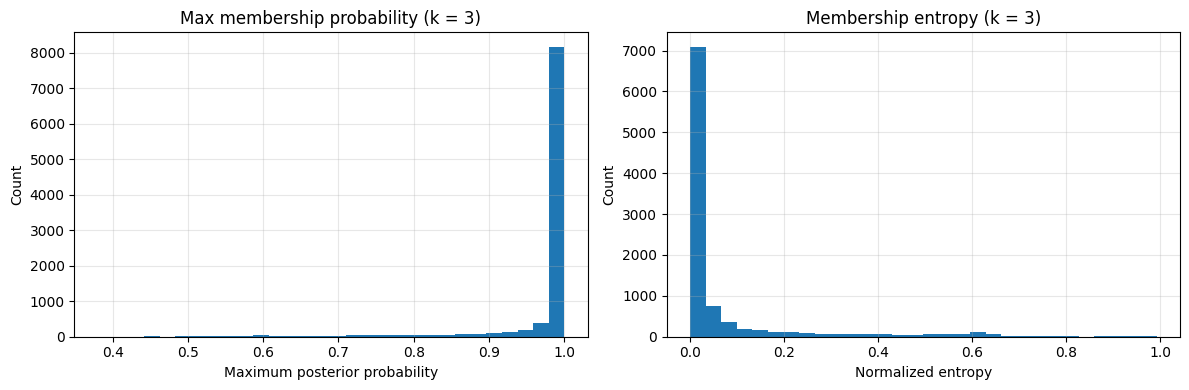

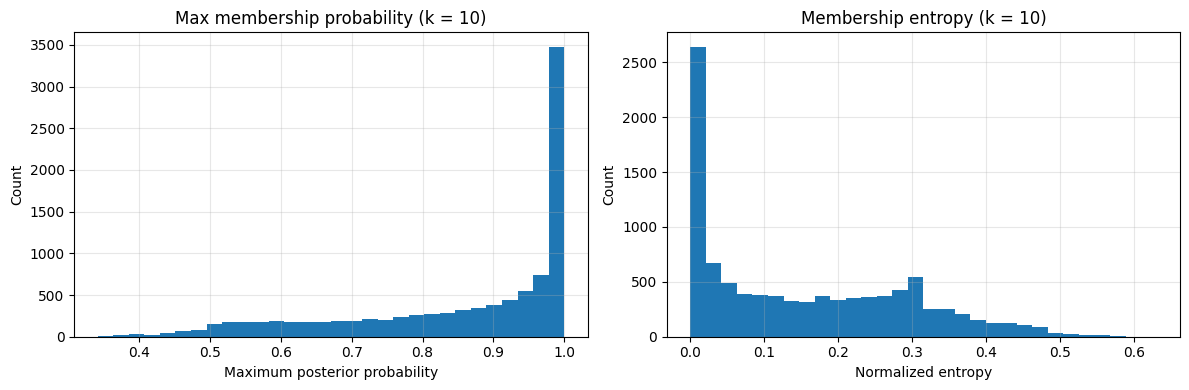

In [36]:
for k in candidate_ks:
    diag = final_diagnostics[k].copy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(diag["max_membership_prob"], bins=30)
    axes[0].set_title(f"Max membership probability (k = {k})")
    axes[0].set_xlabel("Maximum posterior probability")
    axes[0].set_ylabel("Count")
    axes[0].grid(alpha=0.3)

    axes[1].hist(diag["membership_entropy"], bins=30)
    axes[1].set_title(f"Membership entropy (k = {k})")
    axes[1].set_xlabel("Normalized entropy")
    axes[1].set_ylabel("Count")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [39]:
probability_summary_rows = []

for k in candidate_ks:
    diag = final_diagnostics[k].copy()

    by_true_class = (
        diag.groupby("true_class")[["max_membership_prob", "membership_entropy", "is_majority_vote_correct"]]
        .agg({
            "max_membership_prob": ["mean", "median"],
            "membership_entropy": ["mean", "median"],
            "is_majority_vote_correct": "mean",
        })
    )

    print(f"\n=== Membership-probability summary by true class (k = {k}) ===")
    display(by_true_class)

    # uncertain = diag.sort_values(
    #     ["max_membership_prob", "membership_entropy"],
    #     ascending=[True, False]
    # ).head(15)

    # print(f"Most ambiguous objects for k = {k}:")
    # display(uncertain)


=== Membership-probability summary by true class (k = 3) ===


max_membership_prob           membership_entropy                \
                          mean    median               mean        median   
true_class                                                                  
GALAXY                0.969122  0.998261       7.678370e-02  1.194386e-02   
QSO                   0.980188  1.000000       4.197606e-02  5.030168e-11   
STAR                  1.000000  1.000000       5.030168e-11  5.030168e-11   

           is_majority_vote_correct  
                               mean  
true_class                           
GALAXY                     0.954529  
QSO                        0.929927  
STAR                       0.000000


=== Membership-probability summary by true class (k = 10) ===


max_membership_prob           membership_entropy            \
                          mean    median               mean    median   
true_class                                                              
GALAXY                0.840072  0.900458           0.170835  0.157089   
QSO                   0.954376  0.994076           0.056643  0.015816   
STAR                  0.986473  0.999760           0.014322  0.000975   

           is_majority_vote_correct  
                               mean  
true_class                           
GALAXY                     0.999406  
QSO                        0.675912  
STAR                       0.657600

### Interpretation of membership-probability results

For k = 3
- Max membership probability:
  values are very close to 1.0
The model is highly confident in its assignments
- Membership entropy:
  most values are near 0 and assignments are sharp, not spread across clusters
Only a small fraction of points are uncertain (long tail)
- Combined interpretation
  The GMM forms well-defined components internally
  The model is decisive, not fuzzy
  Ambiguity exists only for a small subset of boundary points

For k = 10
- Max membership probability:
  Fewer points at ~1.0 compared to k=3 and many moderately confident assignments
- Membership entropy: 
Entropy is higher overall meaning more uncertain / mixed memberships
- Combined interpretation:
Increasing k → confidence drops + Clusters become less stable and more fragmented +More points lie near cluster boundaries

## 10. PCA visualisation

PCA is used here only as a **2D visual aid**.  

The purpose of these plots is to compare:
- the GMM component assignment,
- the known class labels,
- and the degree to which separation is visually clean or still overlapping.

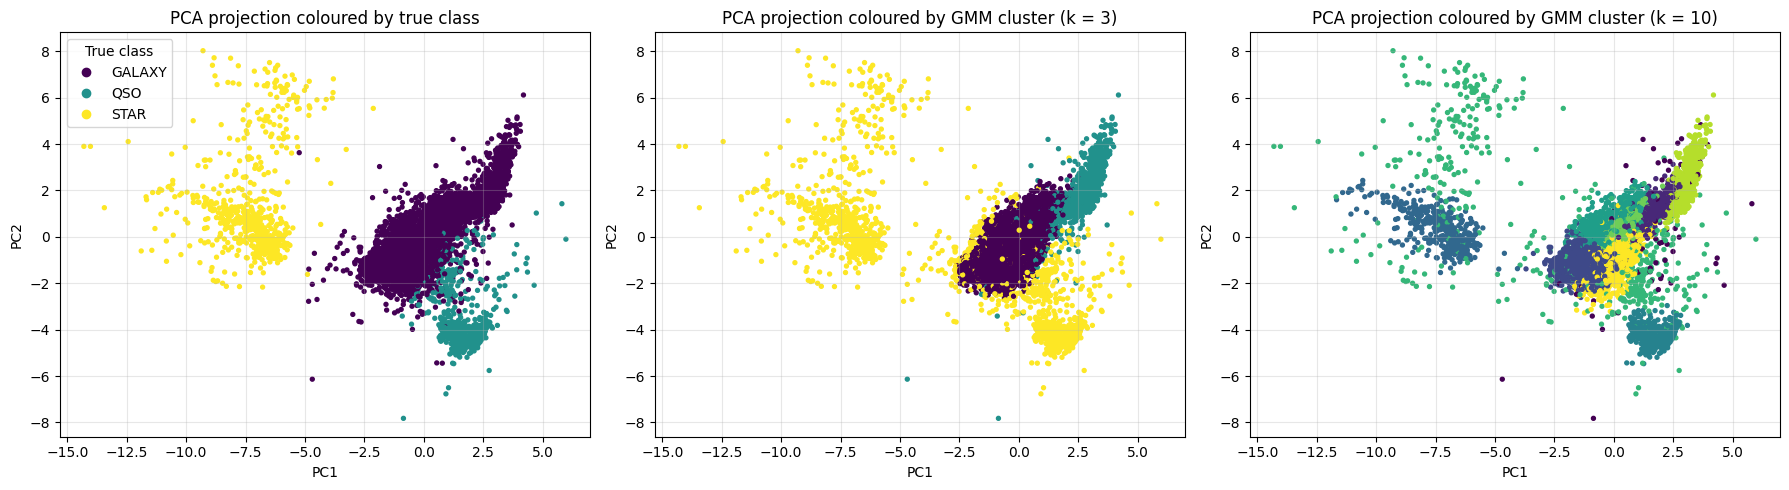

In [38]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

fig, axes = plt.subplots(1, len(candidate_ks) + 1, figsize=(6 * (len(candidate_ks) + 1), 5))

if len(candidate_ks) == 1:
    axes = np.array(axes).reshape(-1)

# Plot true labels
label_codes = pd.Categorical(y)
scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=label_codes.codes, s=8)
axes[0].set_title("PCA projection coloured by true class")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].grid(alpha=0.3)
axes[0].legend(
    handles=scatter.legend_elements()[0],
    labels=list(label_codes.categories),
    title="True class",
    loc="best"
)

# Plot GMM branches
for i, k in enumerate(candidate_ks, start=1):
    labels = final_models[k].predict(X)
    axes[i].scatter(X_pca[:, 0], X_pca[:, 1], c=labels, s=8)
    axes[i].set_title(f"PCA projection coloured by GMM cluster (k = {k})")
    axes[i].set_xlabel("PC1")
    axes[i].set_ylabel("PC2")
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Interpretation of Results

1. **Choice of \(K\)**  
   - BIC was used as the primary criterion. From the plots, K = 10 resulted in the lowest BIC Value. Hence it was chosen alongside K = 3 for number of components in GMM model 

2. **Choice of covariance structure**  
   - The covariance family was selected empirically using BIC/AIC.  

3. **Evaluation outcome**    
   - Model with K = 3 performed better than model with K = 10 across all internal and external metrics(except for cluster purity).
   - This is supporting evidence that k = 3 is an appropirate number of components
   - GMM Model with 3 clusters also outperformed the K means model with 3 clusters (higher NMI). This is expected and the likely reason is the rationale for choosing GMM in the first place

4. **Potential improvement** 
   - Analysis of membership probabilities and the cluster distribution highlights one big issue. 
   - For instance, for model with 3 clusters, the 'stars' data points are being grouped together with QSO. Yet the model remains highly confident in its grouping
   - This suggest that the GMM models are confidently capturing structure, but not necessarily the structure that separate the labels

